In [1]:
import sys
import os

# Move from notebooks/ → project root
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print("Project root added:", PROJECT_ROOT)

Project root added: c:\Users\aayus\OneDrive\Desktop\software-defect-prediction-research


In [2]:
import os
import joblib
import numpy as np
import pandas as pd

def load_data(sample_size=12000):
    paths = [
        "data/processed/encoded.pkl",
        "../data/processed/encoded.pkl"
    ]

    for p in paths:
        if os.path.exists(p):
            print(f"✅ Loaded from {p}")
            df = joblib.load(p)
            break
    else:
        raise FileNotFoundError("Run encoding.py first")

    return df.sample(n=min(sample_size, len(df)), random_state=42)

In [3]:
df = load_data()

target = "defects"

X = df.drop(columns=[target]).values.astype(np.float32)
y = df[target].values.astype(np.int32)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

✅ Loaded from ../data/processed/encoded.pkl


In [4]:
from imblearn.over_sampling import SMOTE, ADASYN

smote = SMOTE(random_state=42)
X_sm, y_sm = smote.fit_resample(X_train, y_train)

adasyn = ADASYN(random_state=42)
X_ad, y_ad = adasyn.fit_resample(X_train, y_train)

In [5]:
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Conv1D, Flatten, Dense # type: ignore

def build_cnn(input_shape):
    model = Sequential()

    model.add(Conv1D(32, 3, activation="relu", input_shape=input_shape))
    model.add(Flatten())
    model.add(Dense(64, activation="relu"))

    # MUST match hybrid architecture
    model.add(Dense(32, activation="relu", name="feature_layer"))

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [6]:
from tensorflow.keras.callbacks import EarlyStopping # type: ignore
import matplotlib.pyplot as plt

def train_cnn(X, y):
    X_cnn = X.reshape(X.shape[0], X.shape[1], 1)

    model = build_cnn((X.shape[1], 1))

    early = EarlyStopping(patience=5, restore_best_weights=True)

    history = model.fit(
        X_cnn, y,
        validation_split=0.2,
        epochs=100,
        batch_size=64,
        verbose=1
    )

    # Plot accuracy
    plt.figure()
    plt.plot(history.history["accuracy"], label="train")
    plt.plot(history.history["val_accuracy"], label="val")
    plt.title("CNN Accuracy vs Epoch")
    plt.legend()
    plt.show()

    return model

In [7]:
from src.models.hybrid_model.hybrid_architecture import HybridModel

def run_hybrid(X_train, y_train, X_test, name):

    print(f"\n🚀 Running Hybrid: {name}")

    # Train CNN
    cnn = train_cnn(X_train, y_train)

    # Hybrid model
    hybrid = HybridModel(cnn)

    hybrid.fit(X_train, y_train)

    preds = hybrid.predict(X_test)

    return preds


🚀 Running Hybrid: Original


Epoch 1/100


120/120 [==============================] - 2s 6ms/step - loss: 1.2759 - accuracy: 0.9214 - val_loss: 2.5197 - val_accuracy: 0.9380
Epoch 2/100
120/120 [==============================] - 0s 4ms/step - loss: 0.3316 - accuracy: 0.9346 - val_loss: 0.1476 - val_accuracy: 0.9427
Epoch 3/100
120/120 [==============================] - 0s 4ms/step - loss: 0.3113 - accuracy: 0.9370 - val_loss: 0.4324 - val_accuracy: 0.9391
Epoch 4/100
120/120 [==============================] - 0s 4ms/step - loss: 0.2015 - accuracy: 0.9395 - val_loss: 0.1449 - val_accuracy: 0.9438
Epoch 5/100
120/120 [==============================] - 0s 4ms/step - loss: 0.2330 - accuracy: 0.9408 - val_loss: 0.6836 - val_accuracy: 0.8010
Epoch 6/100
120/120 [==============================] - 0s 4ms/step - loss: 0.1773 - accuracy: 0.9413 - val_loss: 0.3503 - val_accuracy: 0.9422
Epoch 7/100
120/120 [==============================] - 0s 4ms/step - loss: 0.1872 - accuracy: 0.9427 - val_los

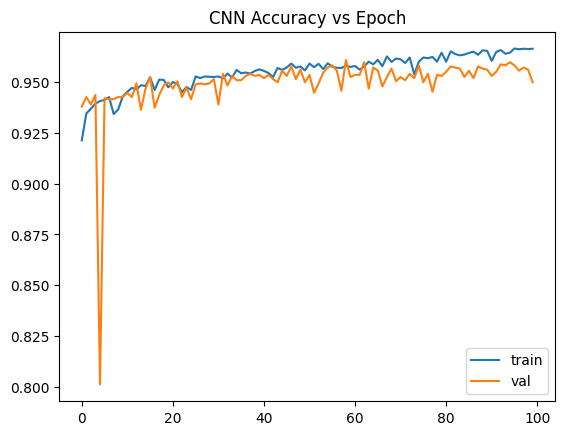

c:\Users\aayus\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [15:51:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\aayus\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [15:51:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\aayus\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [15:51:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\aayus\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [15:51:37] WARNING: C:\actio


🚀 Running Hybrid: SMOTE
Epoch 1/100
203/203 [==============================] - 2s 5ms/step - loss: 0.5603 - accuracy: 0.9009 - val_loss: 0.1297 - val_accuracy: 0.9704
Epoch 2/100
203/203 [==============================] - 1s 4ms/step - loss: 0.2529 - accuracy: 0.9239 - val_loss: 0.0903 - val_accuracy: 0.9957
Epoch 3/100
203/203 [==============================] - 1s 4ms/step - loss: 0.2101 - accuracy: 0.9332 - val_loss: 0.1201 - val_accuracy: 0.9846
Epoch 4/100
203/203 [==============================] - 1s 4ms/step - loss: 0.2113 - accuracy: 0.9324 - val_loss: 0.0807 - val_accuracy: 0.9871
Epoch 5/100
203/203 [==============================] - 1s 4ms/step - loss: 0.1680 - accuracy: 0.9399 - val_loss: 0.3075 - val_accuracy: 0.8925
Epoch 6/100
203/203 [==============================] - 1s 5ms/step - loss: 0.1536 - accuracy: 0.9436 - val_loss: 0.2695 - val_accuracy: 0.8971
Epoch 7/100
203/203 [==============================] - 1s 4ms/step - loss: 0.1554 - accuracy: 0.9443 - val_loss: 0.14

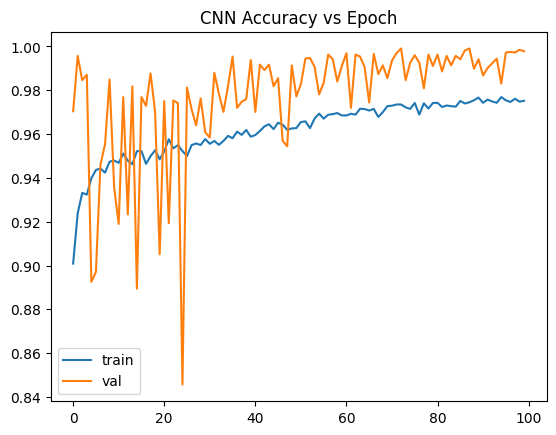

c:\Users\aayus\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [15:53:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\aayus\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [15:53:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\aayus\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [15:53:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🚀 Running Hybrid: ADASYN
Epoch 1/100
202/202 [==============================] - 1s 4ms/step - loss: 1.6321 - accuracy: 0.8434 - val_loss: 0.1763 - val_accuracy: 0.9640
Epoch 2/100
202/202 [==============================] - 1s 3ms/step - loss: 0.2771 - accuracy: 0.8962 - val_loss: 0.0776 - val_accuracy: 0.9879
Epoch 3/100
202/202 [==============================] - 1s 3ms/step - loss: 0.2540 - accuracy: 0.9120 - val_loss: 2.5196 - val_accuracy: 0.5478
Epoch 4/100
202/202 [==============================] - 1s 3ms/step - loss: 0.2117 - accuracy: 0.9220 - val_loss: 0.1937 - val_accuracy: 0.9261
Epoch 5/100
202/202 [==============================] - 1s 3ms/step - loss: 0.2669 - accuracy: 0.9128 - val_loss: 0.4640 - val_accuracy: 0.8172
Epoch 6/100
202/202 [==============================] - 1s 3ms/step - loss: 0.1834 - accuracy: 0.9343 - val_loss: 0.1834 - val_accuracy: 0.9500
Epoch 7/100
202/202 [==============================] - 1s 3ms/step - loss: 0.1981 - accuracy: 0.9279 - val_loss: 0.0

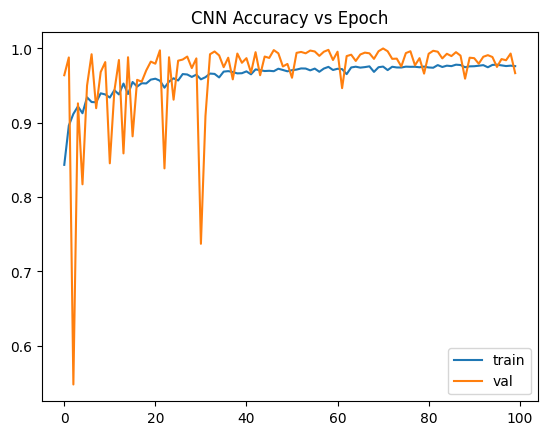

c:\Users\aayus\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [15:54:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\aayus\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [15:54:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\aayus\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [15:54:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\aayus\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [15:54:44] WARNING: C:\actio

In [8]:
results = {}

# Original
results["original"] = run_hybrid(X_train, y_train, X_test, "Original")

# SMOTE
results["smote"] = run_hybrid(X_sm, y_sm, X_test, "SMOTE")

# ADASYN
results["adasyn"] = run_hybrid(X_ad, y_ad, X_test, "ADASYN")

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns

def evaluate(y_true, y_pred, name):
    print(f"\n==== {name} ====")

    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"Hybrid {name} Confusion Matrix")
    plt.show()


==== original ====
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       371
           1       0.98      0.96      0.97      2029

    accuracy                           0.95      2400
   macro avg       0.90      0.93      0.92      2400
weighted avg       0.96      0.95      0.95      2400



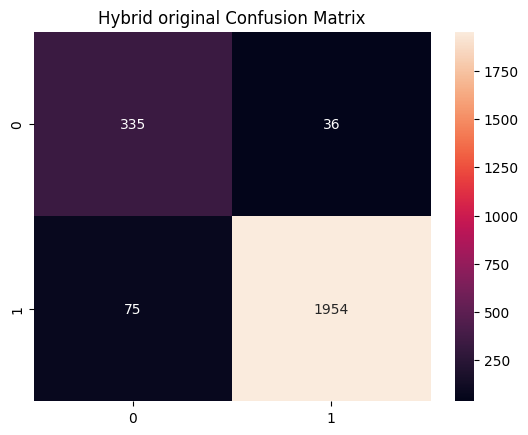


==== smote ====
              precision    recall  f1-score   support

           0       0.80      0.96      0.87       371
           1       0.99      0.96      0.97      2029

    accuracy                           0.96      2400
   macro avg       0.90      0.96      0.92      2400
weighted avg       0.96      0.96      0.96      2400



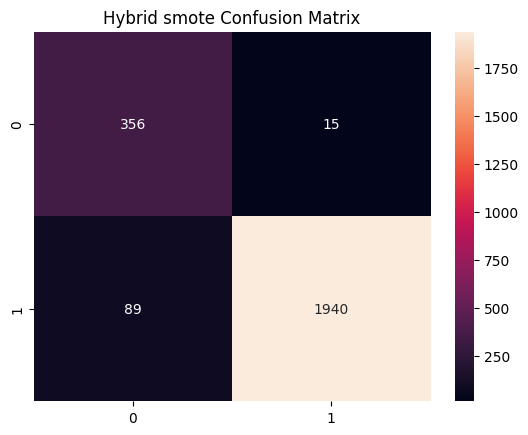


==== adasyn ====
              precision    recall  f1-score   support

           0       0.80      0.93      0.86       371
           1       0.99      0.96      0.97      2029

    accuracy                           0.95      2400
   macro avg       0.89      0.95      0.92      2400
weighted avg       0.96      0.95      0.96      2400



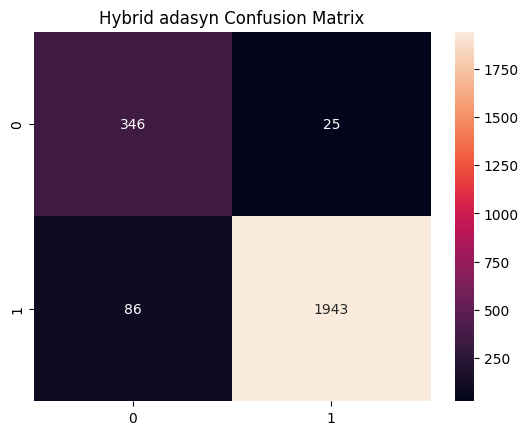

In [10]:
for name, pred in results.items():
    evaluate(y_test, pred, name)

In [11]:
def plot_roc(y_true, y_pred, name):
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"{name} AUC={roc_auc:.2f}")
    plt.plot([0,1],[0,1],'--')
    plt.legend()
    plt.title(name)
    plt.show()

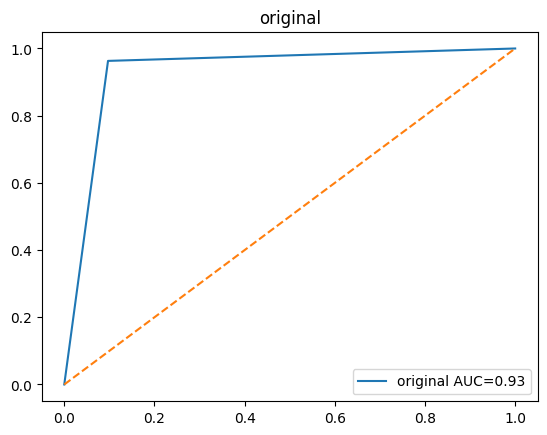

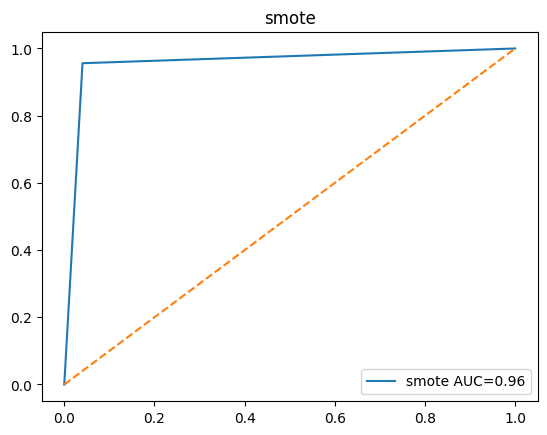

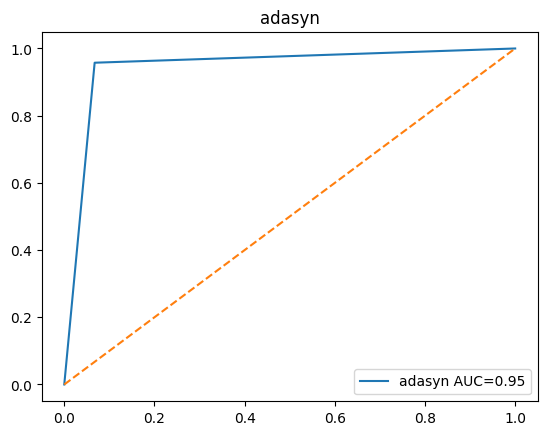

In [12]:
for name, pred in results.items():
    plot_roc(y_test, pred, name)